In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import sys
import glob

## Load CMAPSS Training Dataset

In [ ]:
sys.path.append(os.path.abspath(".."))
from src.data_loader import load_all_training_data
DATA_PATH = r'C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw'
train = load_all_training_data(DATA_PATH)

Searching for files using pattern: C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw\train_FD*.txt
Files detected: ['C:\\Users\\sinha\\Desktop\\ISA Project\\streamlit_ai_dashboard\\data\\raw\\train_FD001.txt', 'C:\\Users\\sinha\\Desktop\\ISA Project\\streamlit_ai_dashboard\\data\\raw\\train_FD002.txt', 'C:\\Users\\sinha\\Desktop\\ISA Project\\streamlit_ai_dashboard\\data\\raw\\train_FD003.txt', 'C:\\Users\\sinha\\Desktop\\ISA Project\\streamlit_ai_dashboard\\data\\raw\\train_FD004.txt']
Loading C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw\train_FD001.txt
Loading C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw\train_FD002.txt
Loading C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw\train_FD003.txt
Loading C:\Users\sinha\Desktop\ISA Project\streamlit_ai_dashboard\data\raw\train_FD004.txt
Total rows loaded: 160359
Total columns: 27


In [133]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   engine_id     160359 non-null  int64  
 1   cycle         160359 non-null  int64  
 2   op_setting_1  160359 non-null  float64
 3   op_setting_2  160359 non-null  float64
 4   op_setting_3  160359 non-null  float64
 5   sensor_1      160359 non-null  float64
 6   sensor_2      160359 non-null  float64
 7   sensor_3      160359 non-null  float64
 8   sensor_4      160359 non-null  float64
 9   sensor_5      160359 non-null  float64
 10  sensor_6      160359 non-null  float64
 11  sensor_7      160359 non-null  float64
 12  sensor_8      160359 non-null  float64
 13  sensor_9      160359 non-null  float64
 14  sensor_10     160359 non-null  float64
 15  sensor_11     160359 non-null  float64
 16  sensor_12     160359 non-null  float64
 17  sensor_13     160359 non-null  float64
 18  sens

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,...,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000
mean,105.553758,123.331338,17.211973,0.410004,95.724344,485.840890,597.361022,1467.035653,1260.956434,9.894999,...,338.789821,2349.645243,8088.950972,9.054747,0.025185,360.698801,2273.754039,98.389146,25.942709,15.565700
std,72.867325,83.538146,16.527988,0.367938,12.359044,30.420388,42.478516,118.175261,136.300073,4.265554,...,164.193480,111.167242,80.623257,0.751581,0.004997,31.021430,142.513114,4.656270,11.691422,7.015067
min,1.000000,1.000000,-0.008700,-0.000600,60.000000,445.000000,535.480000,1242.670000,1023.770000,3.910000,...,128.310000,2027.570000,7845.780000,8.156300,0.020000,302.000000,1915.000000,84.930000,10.160000,6.010500
25%,44.000000,57.000000,0.001300,0.000200,100.000000,449.440000,549.960000,1357.360000,1126.830000,5.480000,...,164.790000,2387.970000,8070.530000,8.439250,0.020000,332.000000,2212.000000,100.000000,14.330000,8.601300
50%,89.000000,114.000000,19.998100,0.620000,100.000000,489.050000,605.930000,1492.810000,1271.740000,9.350000,...,321.690000,2388.070000,8118.590000,9.030100,0.030000,367.000000,2319.000000,100.000000,24.920000,14.953500
75%,164.000000,173.000000,35.001500,0.840000,100.000000,518.670000,642.340000,1586.590000,1402.200000,14.620000,...,521.340000,2388.160000,8139.410000,9.344200,0.030000,392.000000,2388.000000,100.000000,38.820000,23.294600
max,260.000000,543.000000,42.008000,0.842000,100.000000,518.670000,645.110000,1616.910000,1441.490000,14.620000,...,537.490000,2390.490000,8293.720000,11.066900,0.030000,400.000000,2388.000000,100.000000,39.890000,23.950500


In [134]:
train.head(10)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,train_FD001.txt
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,train_FD001.txt
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,train_FD001.txt
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,train_FD001.txt
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,train_FD001.txt
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,train_FD001.txt
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,train_FD001.txt
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,train_FD001.txt
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,train_FD001.txt
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,train_FD001.txt


## Compute Remaining Useful Life (RUL)

In [135]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id','max_cycle']

train = train.merge(max_cycle, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']

train[['engine_id','cycle','RUL']].head()

,engine_id,cycle,RUL
0,1,1,320
1,1,2,319
2,1,3,318
3,1,4,317
4,1,5,316


## RUL Distribution

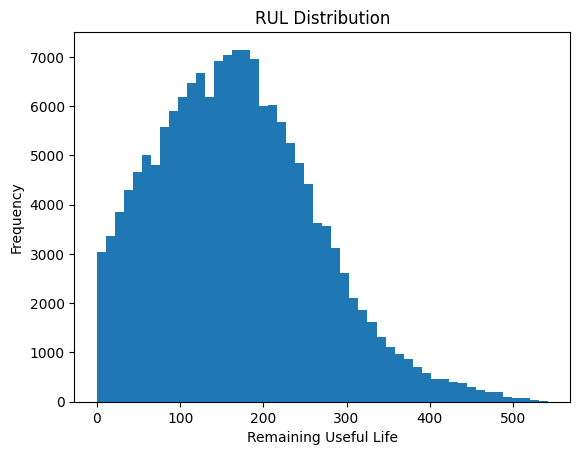

In [136]:
plt.figure()
plt.hist(train['RUL'], bins=50)
plt.title('RUL Distribution')
plt.xlabel('Remaining Useful Life')
plt.ylabel('Frequency')
plt.show()

## Sensor Trend for One Engine

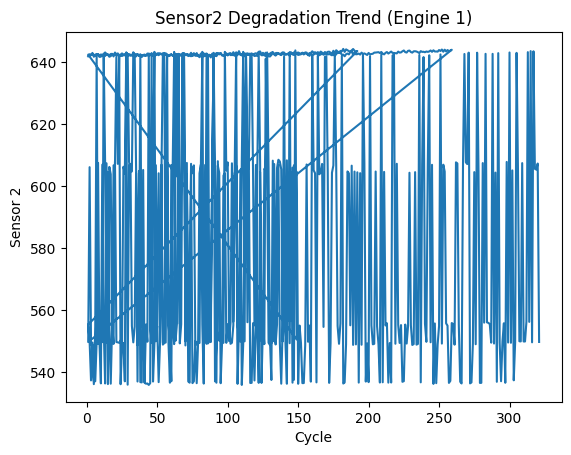

In [137]:
engine_id = 1
engine_data = train[train.engine_id == engine_id]

plt.figure()
plt.plot(engine_data['cycle'], engine_data['sensor_2'])
plt.title('Sensor2 Degradation Trend (Engine 1)')
plt.xlabel('Cycle')
plt.ylabel('Sensor 2')
plt.show()

## Sensor Correlation Heatmap

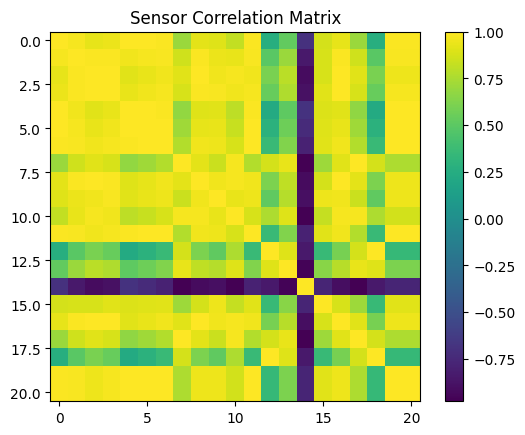

In [138]:
sensor_cols = [c for c in train.columns if 'sensor' in c]
corr = train[sensor_cols].corr()

plt.figure()
plt.imshow(corr)
plt.title('Sensor Correlation Matrix')
plt.colorbar()
plt.show()

## Sensor Importance Ranking (Correlation with RUL)

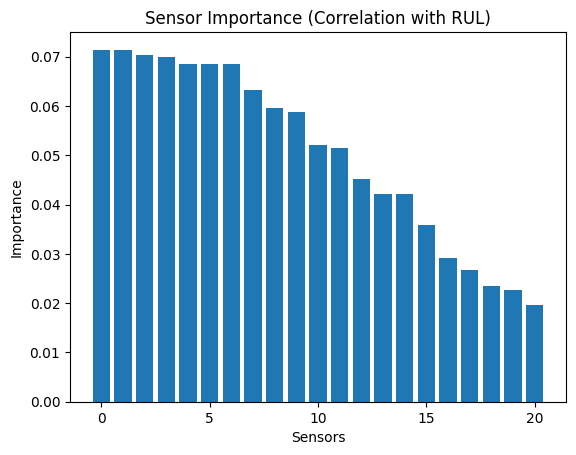

sensor_20    0.071433
sensor_21    0.071401
sensor_6     0.070312
sensor_5     0.069918
sensor_7     0.068604
sensor_1     0.068533
sensor_12    0.068447
sensor_2     0.063187
sensor_10    0.059516
sensor_15    0.058806
dtype: float64

In [140]:
importance = train[sensor_cols].corrwith(train['RUL']).abs()
importance = importance.sort_values(ascending=False)

plt.figure()
plt.bar(range(len(importance)), importance.values)
plt.title('Sensor Importance (Correlation with RUL)')
plt.xlabel('Sensors')
plt.ylabel('Importance')
plt.show()

importance.head(10)

## Health Index Curve for an Engine

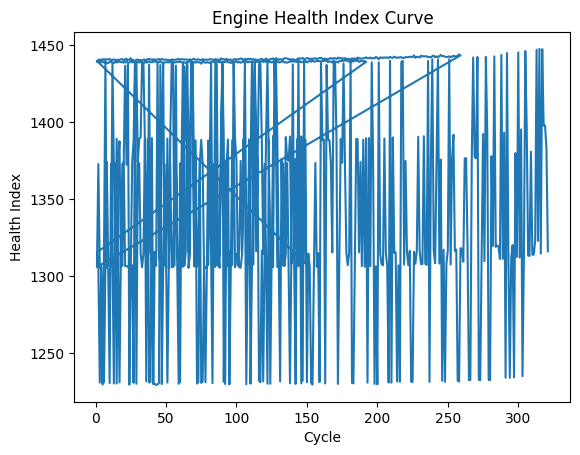

In [141]:
engine_id = 1
engine_data = train[train.engine_id == engine_id]

health_index = engine_data[sensor_cols].mean(axis=1)

plt.figure()
plt.plot(engine_data['cycle'], health_index)
plt.title('Engine Health Index Curve')
plt.xlabel('Cycle')
plt.ylabel('Health Index')
plt.show()